# **Data Cleaning Notebook**

## Objectives

* Drop unused columns
* Clean data

## Inputs

* outputs/datasets/collection/usDOTflightDelay_*.csv'


## Outputs

* Generate cleaned Train and Test sets, both saved under: outputs/datasets/cleaned/


---

# Set working directory

In [1]:
import os
current_dir = os.getcwd()
os.chdir(os.path.dirname(current_dir))
current_dir = os.getcwd()
current_dir

'/workspaces/airline-delay-predictor'

In [2]:
# Disable warnings:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Load data from collections

In [40]:
from dask import dataframe as dd

dtype_map = {
    'CANCELLATION_REASON': 'object',
}

df = dd.read_csv('outputs/datasets/collection/usDOTflightDelay_*.csv', dtype=dtype_map).compute()
df.head(5)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,date,flight_depart_delayed,AIR_SYSTEM_DELAY_pct,SECURITY_DELAY_pct,AIRLINE_DELAY_pct,LATE_AIRCRAFT_DELAY_pct,WEATHER_DELAY_pct
0,2015,1,3,6,DL,1087,N930DL,ATL,DAB,1205,...,0.0,0.0,0.0,2015-01-03,0,0.0,0.0,0.0,0.0,0.0
1,2015,1,21,3,DL,61,N822DN,SFO,ATL,1209,...,0.0,0.0,0.0,2015-01-21,0,0.0,0.0,0.0,0.0,0.0
2,2015,2,9,1,WN,2498,N7711N,RNO,LAS,2125,...,0.0,0.0,0.0,2015-02-09,0,0.0,0.0,0.0,0.0,0.0
3,2015,2,8,7,OO,5659,N787SK,DEN,OKC,1000,...,0.0,0.0,0.0,2015-02-08,0,0.0,0.0,0.0,0.0,0.0
4,2015,2,11,3,WN,2605,N731SA,OMA,PHX,900,...,0.0,0.0,0.0,2015-02-11,0,0.0,0.0,0.0,0.0,0.0


## Columns with missing data

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40000 entries, 0 to 4417
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   YEAR                     40000 non-null  int64  
 1   MONTH                    40000 non-null  int64  
 2   DAY                      40000 non-null  int64  
 3   DAY_OF_WEEK              40000 non-null  int64  
 4   AIRLINE                  40000 non-null  string 
 5   FLIGHT_NUMBER            40000 non-null  int64  
 6   TAIL_NUMBER              40000 non-null  string 
 7   ORIGIN_AIRPORT           40000 non-null  string 
 8   DESTINATION_AIRPORT      40000 non-null  string 
 9   SCHEDULED_DEPARTURE      40000 non-null  int64  
 10  DEPARTURE_TIME           40000 non-null  float64
 11  DEPARTURE_DELAY          40000 non-null  float64
 12  TAXI_OUT                 40000 non-null  float64
 13  WHEELS_OFF               40000 non-null  float64
 14  SCHEDULED_TIME           400

In [41]:
vars_with_missing_data = df.columns[df.isna().sum() > 0].to_list()
vars_with_missing_data

# CANCELLATION_REASON to be dropped

['CANCELLATION_REASON']

## Correlation and PPS

In [42]:
import ppscore as pps
import numpy as np

def heatmap_corr(df,threshold, figsize=(20,12), font_annot = 8):
  if len(df.columns) > 1:
    mask = np.zeros_like(df, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    mask[abs(df) < threshold] = True

    fig, axes = plt.subplots(figsize=figsize)
    sns.heatmap(df, annot=True, xticklabels=True, yticklabels=True,
                mask=mask, cmap='viridis', annot_kws={"size": font_annot}, ax=axes,
                linewidth=0.5
                     )
    
    # if gridlines:
    axes.axhline(y=0, color='k',linewidth=10)
    axes.axhline(y=df.shape[1], color='k',linewidth=10)
    axes.axvline(x=0, color='k',linewidth=10)
    axes.axvline(x=df.shape[0], color='k',linewidth=10)
  
    axes.set_yticklabels(df.columns, rotation = 0)
    plt.ylim(len(df.columns),0)
    plt.show()


def heatmap_pps(df,threshold, figsize=(20,12), font_annot = 8):
    if len(df.columns) > 1:

      mask = np.zeros_like(df, dtype=bool)
      mask[abs(df) < threshold] = True

      fig, ax = plt.subplots(figsize=figsize)
      ax = sns.heatmap(df, annot=True, xticklabels=True,yticklabels=True,
                       mask=mask,cmap='rocket_r', annot_kws={"size": font_annot},
                       linewidth=0.05,linecolor='grey')
      
      # if gridlines:
      ax.axhline(y=0, color='k',linewidth=10)
      ax.axhline(y=df.shape[1], color='k',linewidth=10)
      ax.axvline(x=0, color='k',linewidth=10)
      ax.axvline(x=df.shape[0], color='k',linewidth=10)
      
      plt.ylim(len(df.columns),0)
      plt.show()


def CalculateCorrAndPPS(df):
  df_corr_spearman = df.corr(method="spearman")
  df_corr_pearson = df.corr(method="pearson")

  pps_matrix_raw = pps.matrix(df)
  pps_matrix = pps_matrix_raw.filter(['x', 'y', 'ppscore']).pivot(columns='x', index='y', values='ppscore')

  pps_score_stats = pps_matrix_raw.query("ppscore < 1").filter(['ppscore']).describe().T
  print("--- PPS threshold - PPS score IQR --- \n")
  print(pps_score_stats.round(3))

  return df_corr_pearson, df_corr_spearman, pps_matrix


def DisplayCorrAndPPS(df_corr_pearson, df_corr_spearman, pps_matrix,CorrThreshold,PPS_Threshold,
                      figsize=(20,12), font_annot=8 ):

  print("\n")
  print("*** Heatmap: Spearman Correlation ***")
  heatmap_corr(df=df_corr_spearman, threshold=CorrThreshold, figsize=figsize, font_annot=font_annot)

  print("\n")
  print("*** Heatmap: Pearson Correlation ***")
  heatmap_corr(df=df_corr_pearson, threshold=CorrThreshold, figsize=figsize, font_annot=font_annot)

  print("\n")
  print("*** Heatmap: Predictive power Score (PPS) ***")
  heatmap_pps(df=pps_matrix,threshold=PPS_Threshold, figsize=figsize, font_annot=font_annot)

In [43]:
delay_cols = ['AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY','LATE_AIRCRAFT_DELAY','WEATHER_DELAY']
corr_cols = delay_cols + ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY','SCHEDULED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY','flight_depart_delayed',
       ]
df_corr_pearson, df_corr_spearman, pps_matrix = CalculateCorrAndPPS(df[corr_cols])

--- PPS threshold - PPS score IQR --- 

         count  mean    std  min  25%  50%  75%    max
ppscore  419.0  0.05  0.183  0.0  0.0  0.0  0.0  0.904


In [44]:
corr_pearson_results =df_corr_pearson['flight_depart_delayed'].sort_values(key=abs, ascending=False)[1:]
corr_spearman_results =df_corr_spearman['flight_depart_delayed'].sort_values(key=abs, ascending=False)[1:]
corr_pearson_results

DEPARTURE_DELAY        0.639040
ARRIVAL_DELAY          0.608240
LATE_AIRCRAFT_DELAY    0.443284
AIRLINE_DELAY          0.326158
AIR_SYSTEM_DELAY       0.227674
DEPARTURE_TIME         0.214497
SCHEDULED_DEPARTURE    0.162191
SCHEDULED_ARRIVAL      0.131193
WEATHER_DELAY          0.125081
ARRIVAL_TIME           0.095144
SECURITY_DELAY         0.034256
ELAPSED_TIME           0.030486
MONTH                 -0.028139
SCHEDULED_TIME         0.027374
DISTANCE               0.025393
AIR_TIME               0.023860
DAY_OF_WEEK           -0.014555
TAXI_IN               -0.009563
DAY                   -0.000917
YEAR                        NaN
Name: flight_depart_delayed, dtype: float64



*** Heatmap: Spearman Correlation ***


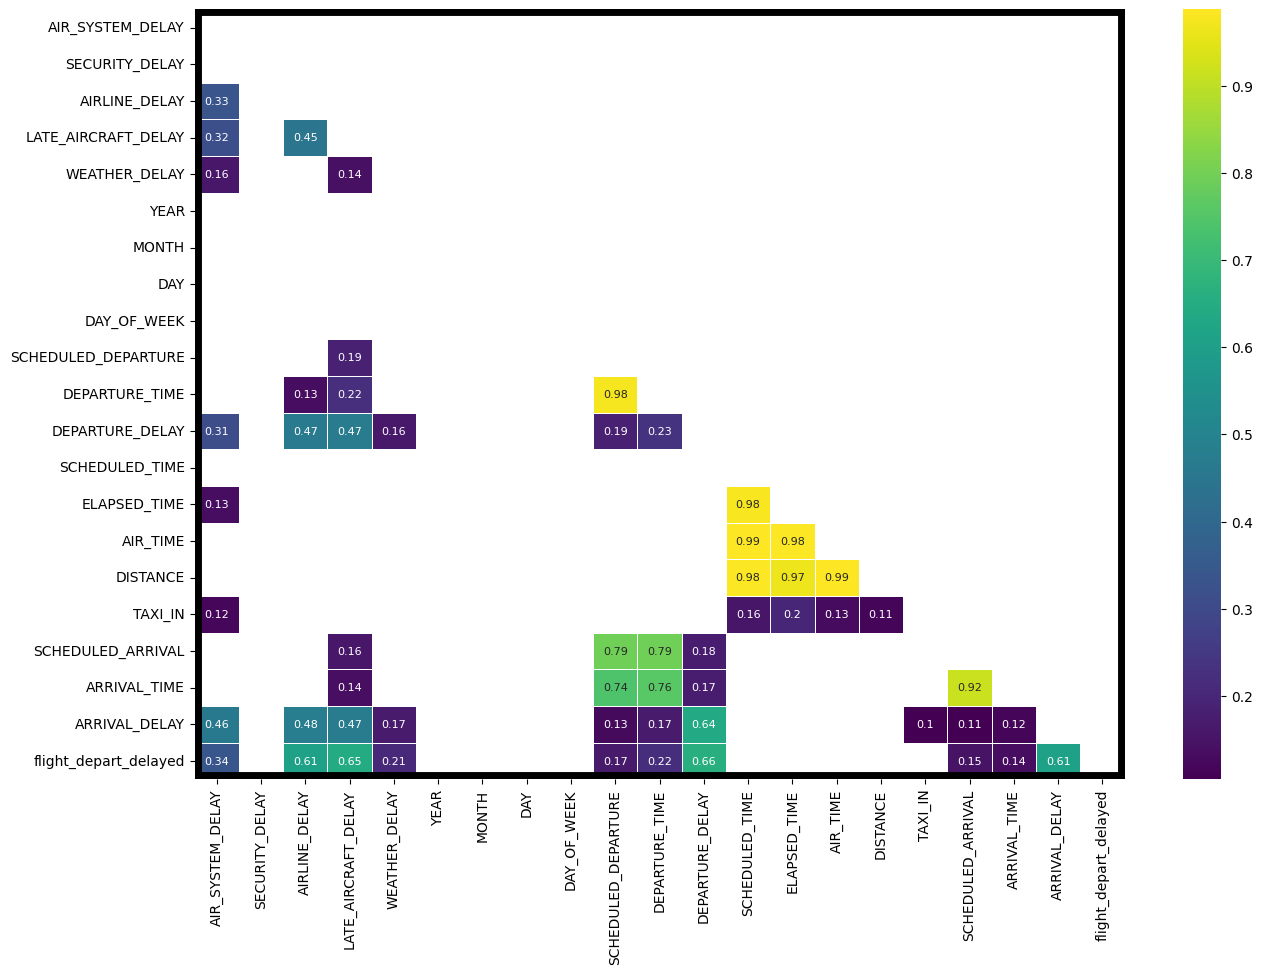



*** Heatmap: Pearson Correlation ***


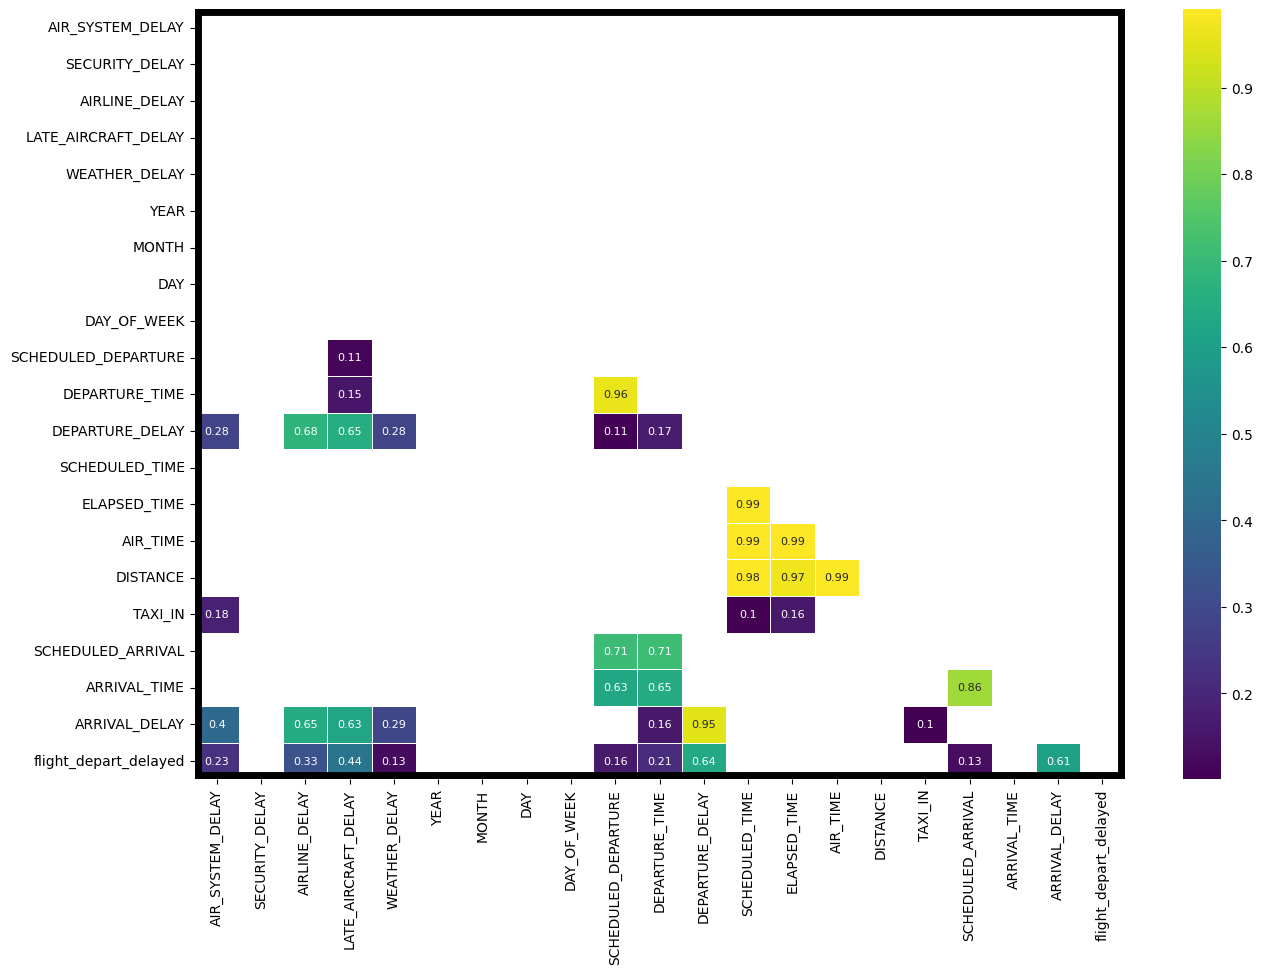



*** Heatmap: Predictive power Score (PPS) ***


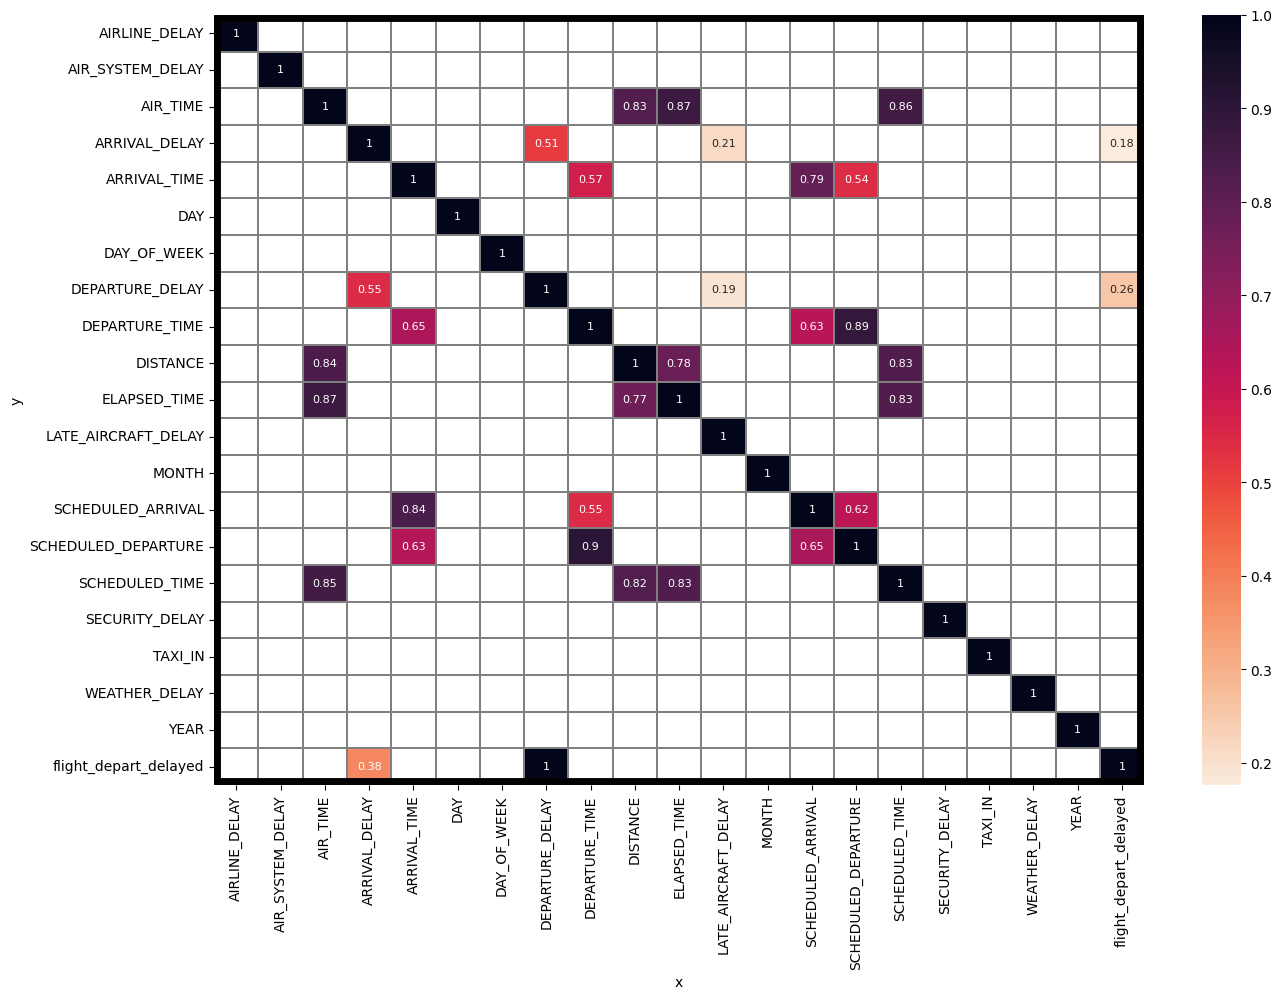

In [45]:
# Display heatmap plots
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

DisplayCorrAndPPS(df_corr_pearson=df_corr_pearson,
                  df_corr_spearman=df_corr_spearman, 
                  pps_matrix=pps_matrix,
                  CorrThreshold=0.1, PPS_Threshold=0.15,
                  figsize=(15,10), font_annot=8)

### Variables to study

In [46]:
# Top variables to study
top_n = 15
vars_to_study = list(set(corr_pearson_results[:top_n].index.to_list() + corr_spearman_results[:top_n].index.to_list()))
vars_to_study 

['AIR_TIME',
 'SCHEDULED_DEPARTURE',
 'DISTANCE',
 'AIRLINE_DELAY',
 'ELAPSED_TIME',
 'LATE_AIRCRAFT_DELAY',
 'ARRIVAL_TIME',
 'MONTH',
 'AIR_SYSTEM_DELAY',
 'DEPARTURE_TIME',
 'ARRIVAL_DELAY',
 'SCHEDULED_ARRIVAL',
 'SECURITY_DELAY',
 'WEATHER_DELAY',
 'DEPARTURE_DELAY',
 'SCHEDULED_TIME']

In [47]:
pps_matrix

x,AIRLINE_DELAY,AIR_SYSTEM_DELAY,AIR_TIME,ARRIVAL_DELAY,ARRIVAL_TIME,DAY,DAY_OF_WEEK,DEPARTURE_DELAY,DEPARTURE_TIME,DISTANCE,...,LATE_AIRCRAFT_DELAY,MONTH,SCHEDULED_ARRIVAL,SCHEDULED_DEPARTURE,SCHEDULED_TIME,SECURITY_DELAY,TAXI_IN,WEATHER_DELAY,YEAR,flight_depart_delayed
y,,,,,,,,,,,,,,,,,,,,,
AIRLINE_DELAY,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
AIR_SYSTEM_DELAY,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
AIR_TIME,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.825780,...,0.000000,0.000000,0.000000,0.000000,0.856230,0.0,0.0,0.0,0.0,0.000000
ARRIVAL_DELAY,0.149344,0.090061,0.000000,1.000000,0.000000,0.000000,0.0,0.512097,0.000000,0.000000,...,0.213044,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.176509
ARRIVAL_TIME,0.000000,0.000000,0.000000,0.000000,1.000000,0.000904,0.0,0.000000,0.572701,0.000000,...,0.000000,0.000609,0.786077,0.542854,0.000000,0.0,0.0,0.0,0.0,0.006295
DAY,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
DAY_OF_WEEK,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
DEPARTURE_DELAY,0.093385,0.000000,0.000000,0.545985,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,...,0.193967,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.255825
DEPARTURE_TIME,0.000000,0.000000,0.000000,0.003384,0.646662,0.000000,0.0,0.018489,1.000000,0.000000,...,0.012856,0.000000,0.626649,0.889344,0.000000,0.0,0.0,0.0,0.0,0.025134


---

# Data Cleaning

**Assess missing data levels:** custom function

In [48]:
def EvaluateMissingData(df):
    missing_data_absolute = df.isnull().sum()
    missing_data_percentage = round(missing_data_absolute/len(df)*100, 2)
    df_missing_data = (pd.DataFrame(
                            data={"RowsWithMissingData": missing_data_absolute,
                                   "PercentageOfDataset": missing_data_percentage,
                                   "DataType": df.dtypes}
                                    )
                          .sort_values(by=['PercentageOfDataset'], ascending=False)
                          .query("PercentageOfDataset > 0")
                          )

    return df_missing_data
EvaluateMissingData(df)

,RowsWithMissingData,PercentageOfDataset,DataType
CANCELLATION_REASON,40000,100.0,string[pyarrow]


In [49]:

df = df.drop(columns=['CANCELLATION_REASON'])
EvaluateMissingData(df)

,RowsWithMissingData,PercentageOfDataset,DataType


### Add more derived variables

In [50]:
# Time of day
df['hour'] = (df['SCHEDULED_DEPARTURE'] // 100).astype(int)
bins = [-1, 5, 11, 17,21, 24]
labels = ['Late Night (0-5am)', 'Morning (6-11am)', 'Afternoon (12pm-5pm)', 'Evening (6pm-9pm)', 'Night (10pm-11pm)']
df['time_of_day'] = pd.cut(df['hour'], bins=bins, labels=labels)

# Main delay factor
df['main_delay'] = df[delay_cols].idxmax(axis=1)



In [ ]:
# Drop unused columns - not related to flight delay
unused_cols = [
 'FLIGHT_NUMBER',
 'TAIL_NUMBER',
 'ORIGIN_AIRPORT',
 'DESTINATION_AIRPORT',
 'SCHEDULED_DEPARTURE',
 'DEPARTURE_TIME',
 'TAXI_OUT',
 'WHEELS_OFF',
 'SCHEDULED_TIME',
 'ELAPSED_TIME',
 'AIR_TIME',
 'WHEELS_ON',
 'TAXI_IN',
 'SCHEDULED_ARRIVAL',
 'ARRIVAL_TIME',
 'ARRIVAL_DELAY',
 'DIVERTED',
 'CANCELLED',
 'hour',
 'date',
]

df = df.drop(columns=unused_cols)
df.info()

### Data Cleaning Summary

* Multiple columns/metrics not related to flight delay were dropped from the dataset, this project is focused on delayed flights and related attributes.

---

## Split Train and Test Sets

In [53]:
from sklearn.model_selection import train_test_split
TrainSet, TestSet, _, __ = train_test_split(
                                        df,
                                        df['flight_depart_delayed'],
                                        test_size=0.2,
                                        random_state=0)

print(f"TrainSet shape: {TrainSet.shape} \nTestSet shape: {TestSet.shape}")

TrainSet shape: (32000, 20) 
TestSet shape: (8000, 20)


In [54]:
df_missing_data = EvaluateMissingData(TrainSet)
print(f"* There are {df_missing_data.shape[0]} variables with missing data \n")
df_missing_data

* There are 0 variables with missing data 



,RowsWithMissingData,PercentageOfDataset,DataType


### Save cleaned Train and Test sets

In [57]:
import os
try:
  os.makedirs(name='outputs/datasets/cleaned')
except Exception as e:
  print(e)

In [58]:
# TestSet
TestSet.to_csv("outputs/datasets/cleaned/TestSetCleaned.csv", index=False)

#TrainSet
TrainSet.to_csv("outputs/datasets/cleaned/TrainSetCleaned.csv", index=False)

# Conclusions and Next Steps

* In case you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create here your folder
  # os.makedirs(name='')
except Exception as e:
  print(e)
